In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

### bars

In [2]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict

# =========================
# PATHS
# =========================

DATA_DIR = Path("/home/moshtasa/Research/phd-svd-recsys/Book/0323_similar_pr_details/SVD-0323/result/SVD-run/data")

OUT_BASE = Path("/home/moshtasa/Research/phd-svd-recsys/Book/0323_similar_pr_details/SVD-0323/result/SVD-run/SVD_bar_figures")
OUT_BASE.mkdir(parents=True, exist_ok=True)

# =========================
# STORAGE
# =========================

results = defaultdict(lambda: defaultdict(dict))

# =========================
# PARSE FILENAME
# =========================

def parse_filename(fname):
    if fname.startswith("ORIGINAL"):
        k = int(re.search(r'(\d+)', fname).group(1))
        return "ORIGINAL", "original", k

    # generalized: matches ANY number of users like 6u, 25u, 2000u
    match = re.match(r"f_(.*?)_(\d+u)_.*?_(\d+)recommendation\.csv", fname)
    if match:
        genre = match.group(1).replace("_s", "'s")
        n = match.group(2)
        k = int(match.group(3))
        return genre, n, k

    return None, None, None

# =========================
# METRIC
# =========================

def compute_avg(df, target_genre):
    df['has_genre'] = df['genres_all'].apply(
        lambda x: target_genre.lower() in x.lower()
    )
    user_counts = df.groupby('user_id')['has_genre'].sum()
    return user_counts.mean(), len(user_counts)

# =========================
# READ NON-ORIGINAL
# =========================

all_n_values = set()

for fname in os.listdir(DATA_DIR):
    if not fname.endswith(".csv"):
        continue

    genre, n, k = parse_filename(fname)
    if genre is None or n == "original":
        continue

    df = pd.read_csv(DATA_DIR / fname)
    avg_val, num_users = compute_avg(df, genre)

    results[genre][k][n] = (avg_val, num_users)
    all_n_values.add(n)

# =========================
# ORIGINAL FILES
# =========================

original_data = defaultdict(dict)

for fname in os.listdir(DATA_DIR):
    if not fname.startswith("ORIGINAL"):
        continue

    _, _, k = parse_filename(fname)
    df = pd.read_csv(DATA_DIR / fname)

    all_genres = set()
    df['genres_all'].str.split(',').apply(
        lambda lst: [all_genres.add(g.strip()) for g in lst]
    )

    for genre in all_genres:
        avg_val, num_users = compute_avg(df.copy(), genre)
        original_data[genre][k] = (avg_val, num_users)

# =========================
# MERGE ORIGINAL
# =========================

for genre in results.keys():
    for k in results[genre].keys():
        if genre in original_data and k in original_data[genre]:
            results[genre][k]['original'] = original_data[genre][k]

# =========================
# COLORS (dynamic)
# =========================

def generate_colors(n_list):
    cmap = plt.cm.get_cmap('tab20', len(n_list))
    return {n: cmap(i) for i, n in enumerate(n_list)}

# =========================
# PLOTTING
# =========================

for genre, k_data in results.items():

    ks = sorted(k_data.keys())

    # dynamically collect all n types including original
    n_types = sorted(set(
        n for k in ks for n in k_data[k].keys()
    ), key=lambda x: (x != "original", int(x.replace("u", "")) if x != "original" else -1))

    color_map = generate_colors(n_types)

    x = np.arange(len(ks)) * 1.4
    width = 0.8 / len(n_types)

    fig, ax = plt.subplots(figsize=(11, 6))

    max_val = 0
    bar_containers = []

    for i, n in enumerate(n_types):
        vals = []
        for k in ks:
            val = k_data[k].get(n, (0, 0))[0]
            vals.append(val)

        bars = ax.bar(
            x + (i - len(n_types)/2) * width + width/2,
            vals,
            width=width,
            color=color_map[n],
            edgecolor="black",
            linewidth=0.6,
            label=n
        )

        bar_containers.append((bars, vals))
        max_val = max(max_val, max(vals))

    # =========================
    # STYLE
    # =========================

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_position(("outward", 5))

    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

    ax.set_title(f"SVD - {genre}", fontsize=14)
    ax.set_xlabel("k (recommendation size)")
    ax.set_ylabel("Avg count per user")

    ax.set_xticks(x)
    ax.set_xticklabels(ks)

    ax.legend()

    # =========================
    # BAR LABELS (horizontal rotation for readability)
    # =========================

    for bars, vals in bar_containers:
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + max_val * 0.01,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=7,
                rotation=90,
            )

    # Add extra headroom so vertical labels don't get clipped
    ax.set_ylim(top=max_val * 1.22)

    # =========================
    # SAVE FIGURE
    # =========================

    genre_folder = OUT_BASE / f"svd_{genre.lower().replace(' ', '_')}_analysis"
    genre_folder.mkdir(parents=True, exist_ok=True)

    fig_path = genre_folder / f"SVD - {genre}.png"

    plt.tight_layout()
    plt.savefig(fig_path, dpi=300)
    plt.close()

    # =========================
    # SAVE EXPLANATION TEXT
    # =========================

    explanation_path = genre_folder / f"SVD - {genre}.txt"

    with open(explanation_path, "w") as f:
        f.write(f"SVD Analysis for Genre: {genre}\n\n")
        f.write("Metric: Average count of target genre per user\n\n")

        for k in ks:
            f.write(f"k = {k}\n")
            for n in n_types:
                val, users = k_data[k].get(n, (0, 0))
                f.write(f"  {n}: {val:.4f} (users={users})\n")
            f.write("\n")

print("All SVD figures and explanation files saved.")

/tmp/ipykernel_3898615/3160162380.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(n_list))
/tmp/ipykernel_3898615/3160162380.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(n_list))
/tmp/ipykernel_3898615/3160162380.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(n_list))
/tmp/ipykernel_3898615/3160162380.py:110: MatplotlibDeprecationWarn

All SVD figures and explanation files saved.


### paramethers

In [3]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ── Paths ──
BASE = "/home/moshtasa/Research/phd-svd-recsys/Book/0323_similar_pr_details/SVD-0323/result/SVD-run"
BI_DIR = os.path.join(BASE, "bi")
MU_DIR = os.path.join(BASE, "mio")
MERGED_DIR = os.path.join(BASE, "merged")
FIG_DIR = os.path.join(BASE, "SVD_details_figures")

os.makedirs(MERGED_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# ── Step 1: Discover all bi files and parse (genre, n) from filenames ──
# Pattern: f_{Genre}_{N}u_pos5_neg1_books_bi_per_genre.csv
BI_PATTERN = re.compile(r"^f_(.+?)_(\d+)u_pos5_neg1_books_bi_per_genre\.csv$")
MU_PATTERN = re.compile(r"^f_(.+?)_(\d+)u_pos5_neg1_books_mu_per_genre\.csv$")

# Collect all (genre_key, n) pairs from bi folder
bi_files = {}
for fname in os.listdir(BI_DIR):
    m = BI_PATTERN.match(fname)
    if m:
        genre_key = m.group(1)   # e.g. "Adult", "Science_Fiction"
        n = int(m.group(2))
        bi_files[(genre_key, n)] = fname

# ── Step 2: Merge bi + mu files and save ──
merged_data = {}  # (genre_key, n) -> merged DataFrame

for (genre_key, n), bi_fname in sorted(bi_files.items()):
    mu_fname = bi_fname.replace("_bi_", "_mu_").replace("/bi/", "/mio/")
    bi_path = os.path.join(BI_DIR, bi_fname)
    mu_path = os.path.join(MU_DIR, mu_fname)

    if not os.path.exists(mu_path):
        print(f"WARNING: No matching mu file for {bi_fname}, skipping.")
        continue

    df_bi = pd.read_csv(bi_path)
    df_mu = pd.read_csv(mu_path)

    # Merge on genre (and is_target if present in both)
    merge_cols = ["genre"]
    if "is_target" in df_bi.columns and "is_target" in df_mu.columns:
        merge_cols.append("is_target")

    df_merged = pd.merge(df_mu, df_bi, on=merge_cols, how="outer")

    # Save merged file
    merged_fname = bi_fname.replace("_bi_", "_merged_")
    merged_path = os.path.join(MERGED_DIR, merged_fname)
    df_merged.to_csv(merged_path, index=False)

    merged_data[(genre_key, n)] = df_merged

# Also merge the ORIGINAL files if they exist
orig_bi = os.path.join(BI_DIR, "ORIGINAL_bi_per_genre.csv")
orig_mu = os.path.join(MU_DIR, "ORIGINAL_mu_per_genre.csv")
if os.path.exists(orig_bi) and os.path.exists(orig_mu):
    df_obi = pd.read_csv(orig_bi)
    df_omu = pd.read_csv(orig_mu)
    merge_cols = ["genre"]
    if "is_target" in df_obi.columns and "is_target" in df_omu.columns:
        merge_cols.append("is_target")
    df_orig_merged = pd.merge(df_omu, df_obi, on=merge_cols, how="outer")
    df_orig_merged.to_csv(os.path.join(MERGED_DIR, "ORIGINAL_merged_per_genre.csv"), index=False)

print(f"Merged {len(merged_data)} file pairs into {MERGED_DIR}")

# ── Step 3: Create one figure per target genre ──
# Group by genre_key to get all n values for that target genre
from collections import defaultdict

genre_groups = defaultdict(dict)  # genre_key -> {n: DataFrame}
for (genre_key, n), df in merged_data.items():
    genre_groups[genre_key][n] = df

# Style
plt.style.use("seaborn-v0_8-pastel")
TARGET_COLOR = "#5B3A29"           # chocolate brown
TARGET_LINEWIDTH = 3.5
NON_TARGET_LINEWIDTH = 1.5

# Distinct pastel colours for non-target genres
PASTEL_COLORS = [
    "#AEC6CF",  # pastel blue
    "#FFD1DC",  # pastel pink
    "#B5EAD7",  # pastel green
    "#FFDAC1",  # pastel peach
    "#C3B1E1",  # pastel lavender
    "#F3E5AB",  # pastel yellow
    "#FFB7B2",  # pastel salmon
    "#B0E0E6",  # powder blue
    "#D5AAFF",  # pastel purple
    "#FFFACD",  # lemon chiffon
    "#E0BBE4",  # pastel mauve
    "#957DAD",  # muted purple
    "#D4E157",  # pastel lime
    "#80CBC4",  # pastel teal
    "#F48FB1",  # pastel rose
]

for genre_key, n_dict in sorted(genre_groups.items()):
    # Sort n values numerically
    sorted_ns = sorted(n_dict.keys())

    # Determine the target genre name from the is_target column
    sample_df = n_dict[sorted_ns[0]]
    target_rows = sample_df[sample_df["is_target"] == "target"]
    if target_rows.empty:
        print(f"WARNING: No target genre found in {genre_key} files, skipping figure.")
        continue
    target_genre_name = target_rows["genre"].iloc[0]

    # Collect all genre names across all n values
    all_genres = set()
    for n in sorted_ns:
        all_genres.update(n_dict[n]["genre"].tolist())
    all_genres = sorted(all_genres)

    # Build data: for each genre, collect (n, avg_bi + global_mean_mu)
    genre_series = {}  # genre_name -> [(n, value), ...]
    for genre_name in all_genres:
        points = []
        for n in sorted_ns:
            df = n_dict[n]
            row = df[df["genre"] == genre_name]
            if not row.empty:
                val = row["avg_bi"].values[0] + row["global_mean_mu"].values[0]
                points.append((n, val))
        genre_series[genre_name] = points

    non_target_genres = [g for g in all_genres if g != target_genre_name]

    # Assign a distinct pastel colour to each non-target genre
    color_map = {}
    for i, g in enumerate(non_target_genres):
        color_map[g] = PASTEL_COLORS[i % len(PASTEL_COLORS)]
    color_map[target_genre_name] = TARGET_COLOR

    # Evenly-spaced x positions
    positions = list(range(len(sorted_ns)))
    n_to_pos = {n: p for n, p in zip(sorted_ns, positions)}

    fig, ax = plt.subplots(figsize=(14, 8))

    # Plot non-target genres (each its own colour)
    for genre_name in non_target_genres:
        pts = genre_series[genre_name]
        if pts:
            xs = [n_to_pos[x] for x, _ in pts]
            ys = [y for _, y in pts]
            ax.plot(xs, ys, marker="o", color=color_map[genre_name],
                    linewidth=NON_TARGET_LINEWIDTH, markersize=5,
                    label=genre_name, alpha=0.8)

    # Plot target genre on top (bold, chocolate brown)
    pts = genre_series[target_genre_name]
    if pts:
        xs = [n_to_pos[x] for x, _ in pts]
        ys = [y for _, y in pts]
        ax.plot(xs, ys, marker="o", color=TARGET_COLOR,
                linewidth=TARGET_LINEWIDTH, markersize=7,
                label=f"{target_genre_name} (target)", zorder=10)

    pretty_genre = genre_key.replace("_", " ")

    ax.set_title(f"SVD - {pretty_genre}", fontsize=16)
    ax.set_xlabel("Number of Fictitious Users (n)", fontsize=13)
    ax.set_ylabel(r"$\mu$ + $b_i$", fontsize=13)
    ax.set_xticks(positions)
    ax.set_xticklabels([str(n) for n in sorted_ns], rotation=45)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    fig_path = os.path.join(FIG_DIR, f"{genre_key}_SVD_parameters.png")
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved figure: {fig_path}")

print("Done!")


Merged 143 file pairs into /home/moshtasa/Research/phd-svd-recsys/Book/0323_similar_pr_details/SVD-0323/result/SVD-run/merged
Saved figure: /home/moshtasa/Research/phd-svd-recsys/Book/0323_similar_pr_details/SVD-0323/result/SVD-run/SVD_details_figures/Adult_SVD_parameters.png
Saved figure: /home/moshtasa/Research/phd-svd-recsys/Book/0323_similar_pr_details/SVD-0323/result/SVD-run/SVD_details_figures/Adventure_SVD_parameters.png
Saved figure: /home/moshtasa/Research/phd-svd-recsys/Book/0323_similar_pr_details/SVD-0323/result/SVD-run/SVD_details_figures/Children_s_SVD_parameters.png
Saved figure: /home/moshtasa/Research/phd-svd-recsys/Book/0323_similar_pr_details/SVD-0323/result/SVD-run/SVD_details_figures/Classics_SVD_parameters.png
Saved figure: /home/moshtasa/Research/phd-svd-recsys/Book/0323_similar_pr_details/SVD-0323/result/SVD-run/SVD_details_figures/Drama_SVD_parameters.png
Saved figure: /home/moshtasa/Research/phd-svd-recsys/Book/0323_similar_pr_details/SVD-0323/result/SVD-run/S

### styletest only

Saved figure to: /home/moshtasa/Research/phd-svd-recsys/Book/0323_similar_pr_details/SVD-0323/result/SVD-run/STYLE/svd_adult_analysis/SVD - Adult.png


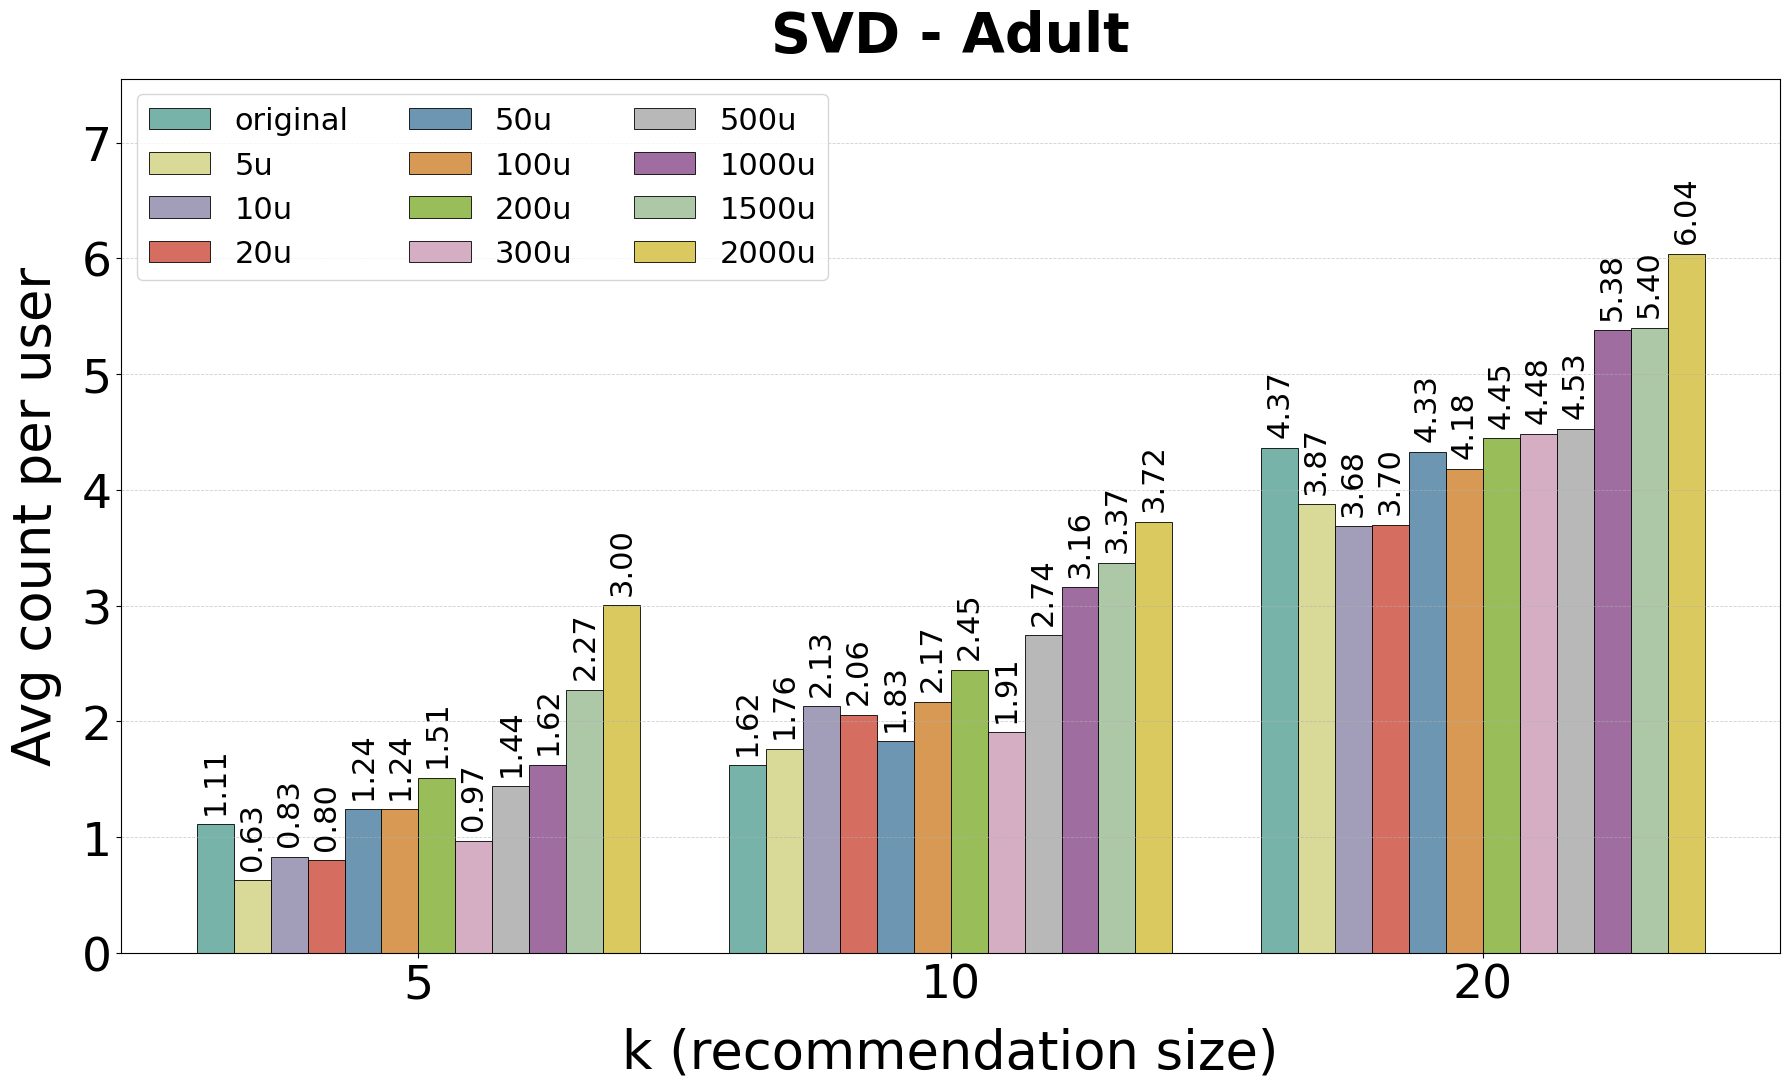

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import random
from pathlib import Path  # <<< FIXED

# =========================
# CONFIG
# =========================

TARGET_GENRE = "Adult"

OUT_DIR = Path("/home/moshtasa/Research/phd-svd-recsys/Book/0323_similar_pr_details/SVD-0323/result/SVD-run/STYLE/svd_adult_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# FAKE DATA GENERATION
# =========================

results = defaultdict(lambda: defaultdict(dict))

ks = [5, 10, 20]

n_types = [
    "original", "5u", "10u", "20u", "50u",
    "100u", "200u", "300u", "500u",
    "1000u", "1500u", "2000u"
]

random.seed(42)

for k in ks:
    for n in n_types:
        base = k * 0.2
        noise = random.uniform(-0.4, 0.4)

        if n == "original":
            val = base + noise
        else:
            scale = int(n.replace("u", "")) * 0.001
            val = base + scale + noise

        val = max(0, val)
        results[TARGET_GENRE][k][n] = (val, 100)

# =========================
# COLORS
# =========================

def generate_pastel_colors(n):
    base = plt.cm.Set3(np.linspace(0, 1, n))
    return [(c[0]*0.85, c[1]*0.85, c[2]*0.85, 1) for c in base]

# =========================
# PLOTTING
# =========================

k_data = results[TARGET_GENRE]
ks = sorted(k_data.keys())

n_types = sorted(set(
    n for k in ks for n in k_data[k].keys()
), key=lambda x: (x != "original", int(x.replace("u", "")) if x != "original" else -1))

colors = generate_pastel_colors(len(n_types))
color_map = {n: colors[i] for i, n in enumerate(n_types)}

x = np.arange(len(ks)) * 1.2
width = 1.0 / len(n_types)

fig, ax = plt.subplots(figsize=(18, 11))  # <<< ONLY CHANGE (bigger figure)

max_val = 0
bar_containers = []

for i, n in enumerate(n_types):
    vals = [k_data[k].get(n, (0, 0))[0] for k in ks]

    bars = ax.bar(
        x + (i - len(n_types)/2) * width + width/2,
        vals,
        width=width,
        color=color_map[n],
        edgecolor="black",
        linewidth=0.6,
        label=n
    )

    bar_containers.append((bars, vals))
    max_val = max(max_val, max(vals))

# =========================
# STYLE
# =========================

ax.spines["top"].set_visible(True)   # <<< FIXED
ax.spines["right"].set_visible(True) # <<< FIXED

ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

ax.set_title(
    f"SVD - {TARGET_GENRE}",
    fontsize=40,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("k (recommendation size)", fontsize=38, labelpad=14)
ax.set_ylabel("Avg count per user", fontsize=38, labelpad=14)

ax.set_xticks(x)
ax.set_xticklabels(ks, fontsize=34)
ax.tick_params(axis='y', labelsize=34)

ax.legend(fontsize=22, ncol=3)

# =========================
# BAR LABELS
# =========================

for bars, vals in bar_containers:
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + max_val * 0.015,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=22,
            rotation=90,
        )

ax.set_ylim(top=max_val * 1.25)

# =========================
# SAVE (BEFORE SHOW)
# =========================

output_file = OUT_DIR / f"SVD - {TARGET_GENRE}.png"

plt.tight_layout()
plt.savefig(output_file, dpi=300)

print(f"Saved figure to: {output_file}")

# =========================
# SHOW
# =========================

plt.show()